In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import os

device = "mps" if torch.mps.is_available() else "cpu"
print("Using device:", device)

Using device: mps


In [6]:
IMAGE_SIZE = 32
PATCH_SIZE = 4
CHANNELS = 3
NUM_CLASSES = 10  # original model had 10 classes
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, patch_size, patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

In [8]:

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.dropout(torch.nn.functional.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

In [9]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

In [11]:
model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES,
    EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)


In [13]:

model.load_state_dict(torch.load("vision_transformer_cifar10.pth", map_location=device))
print("Pretrained model loaded successfully.")

Pretrained model loaded successfully.


In [14]:
for param in model.parameters():
    param.requires_grad = False

# Replace last layer for binary classification (2 classes)
model.head = nn.Linear(EMBED_DIM, 1)   # 1 output for BCE
model.head.requires_grad = True
model = model.to(device)

In [15]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [17]:

train_data = datasets.ImageFolder("training", transform=transform)
test_data = datasets.ImageFolder("testing", transform=transform)

In [18]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [19]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-4)

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.float().to(device)
            y = y.unsqueeze(1)
            logits = model(x)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [21]:
# EPOCHS = 50

# for epoch in range(EPOCHS):
#     model.train()
#     for x, y in train_loader:
#         x, y = x.to(device), y.float().to(device)
#         y = y.unsqueeze(1)
#         optimizer.zero_grad()
#         logits = model(x)
#         loss = criterion(logits, y)
#         loss.backward()
#         optimizer.step()

#     test_acc = evaluate(test_loader)
#     print(f"Epoch {epoch+1}/{EPOCHS} | Test Accuracy: {test_acc:.4f}")

# print("Fine-tuning completed.")

Epoch 1/50 | Test Accuracy: 0.8754
Epoch 2/50 | Test Accuracy: 0.8771
Epoch 3/50 | Test Accuracy: 0.8805
Epoch 4/50 | Test Accuracy: 0.8822
Epoch 5/50 | Test Accuracy: 0.8822
Epoch 6/50 | Test Accuracy: 0.8889
Epoch 7/50 | Test Accuracy: 0.8956
Epoch 8/50 | Test Accuracy: 0.8990
Epoch 9/50 | Test Accuracy: 0.9007
Epoch 10/50 | Test Accuracy: 0.9057
Epoch 11/50 | Test Accuracy: 0.9074
Epoch 12/50 | Test Accuracy: 0.9074
Epoch 13/50 | Test Accuracy: 0.9074
Epoch 14/50 | Test Accuracy: 0.9091
Epoch 15/50 | Test Accuracy: 0.9108
Epoch 16/50 | Test Accuracy: 0.9108
Epoch 17/50 | Test Accuracy: 0.9091
Epoch 18/50 | Test Accuracy: 0.9091
Epoch 19/50 | Test Accuracy: 0.9091
Epoch 20/50 | Test Accuracy: 0.9108
Epoch 21/50 | Test Accuracy: 0.9125
Epoch 22/50 | Test Accuracy: 0.9175
Epoch 23/50 | Test Accuracy: 0.9192
Epoch 24/50 | Test Accuracy: 0.9226
Epoch 25/50 | Test Accuracy: 0.9226
Epoch 26/50 | Test Accuracy: 0.9242
Epoch 27/50 | Test Accuracy: 0.9259
Epoch 28/50 | Test Accuracy: 0.9259
E

In [23]:
save_path = "vision_transformer_binary_finetuned.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved successfully to {save_path}")

Model saved successfully to vision_transformer_binary_finetuned.pth


In [24]:
train_accuracies = []
test_accuracies = []

EPOCHS = 70

for epoch in range(EPOCHS):
    model.train()
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.float().to(device)
        y = y.unsqueeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        # Calculate train accuracy per batch
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    test_acc = evaluate(test_loader)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


Epoch 1/10 | Train Acc: 0.9063 | Test Acc: 0.9377
Epoch 2/10 | Train Acc: 0.9041 | Test Acc: 0.9377
Epoch 3/10 | Train Acc: 0.8976 | Test Acc: 0.9377
Epoch 4/10 | Train Acc: 0.9041 | Test Acc: 0.9411
Epoch 5/10 | Train Acc: 0.9066 | Test Acc: 0.9411
Epoch 6/10 | Train Acc: 0.9074 | Test Acc: 0.9411
Epoch 7/10 | Train Acc: 0.9041 | Test Acc: 0.9411
Epoch 8/10 | Train Acc: 0.9023 | Test Acc: 0.9411
Epoch 9/10 | Train Acc: 0.9048 | Test Acc: 0.9411
Epoch 10/10 | Train Acc: 0.9045 | Test Acc: 0.9411


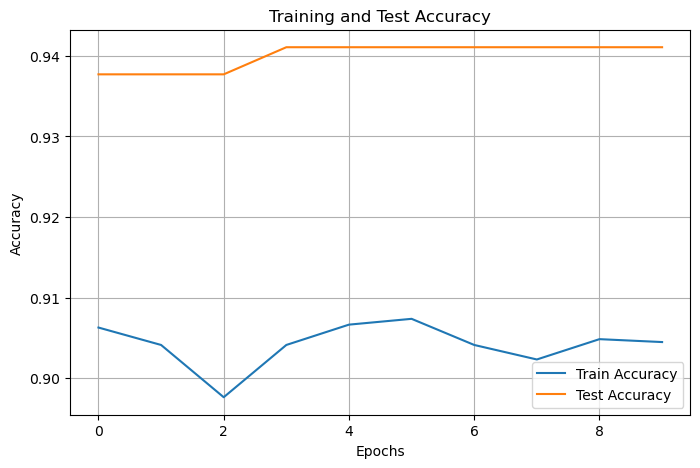

Model saved to vision_transformer_binary_finetuned.pth


In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Save fine-tuned binary model
save_path = "vision_transformer_binary_finetuned.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")


In [26]:
from sklearn.metrics import precision_recall_fscore_support, classification_report
import numpy as np

# Function to get all predictions and true labels
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = (torch.sigmoid(logits) > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions for test set
y_pred, y_true = get_all_predictions(model, test_loader, device)

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1])

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))


Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.93      0.94       297
        Fake       0.93      0.95      0.94       297

    accuracy                           0.94       594
   macro avg       0.94      0.94      0.94       594
weighted avg       0.94      0.94      0.94       594

